<a href="https://colab.research.google.com/github/Dreeck/ProyectosML/blob/Proyecto2/billetesfalsos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication.txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
import plotly.express as px


In [ ]:
Billetes = pd.read_csv('data_banknote_authentication.txt',sep=',', low_memory=False)
Billetes.head()

,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [ ]:
# prompt: Ponle etiquetas de cabeceras de cada columna los siguientes datos, Varianza,  Asimetría, Curtosis, Entropía y Clase

Billetes.columns = ['Varianza', 'Asimetría', 'Curtosis', 'Entropía', 'Clase']
print(Billetes.head())


   Varianza  Asimetría  Curtosis  Entropía  Clase
0   4.54590     8.1674   -2.4586  -1.46210      0
1   3.86600    -2.6383    1.9242   0.10645      0
2   3.45660     9.5228   -4.0112  -3.59440      0
3   0.32924    -4.4552    4.5718  -0.98880      0
4   4.36840     9.6718   -3.9606  -3.16250      0


In [ ]:

print(Billetes.describe())

          Varianza    Asimetría     Curtosis     Entropía        Clase
count  1371.000000  1371.000000  1371.000000  1371.000000  1371.000000
mean      0.431410     1.917434     1.400694    -1.192200     0.444931
std       2.842494     5.868359     4.310105     2.101683     0.497139
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.774700    -1.711300    -1.553350    -2.417000     0.000000
50%       0.495710     2.313400     0.616630    -0.586650     0.000000
75%       2.814650     6.813100     3.181600     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


Clase
0    761
1    610
Name: count, dtype: int64


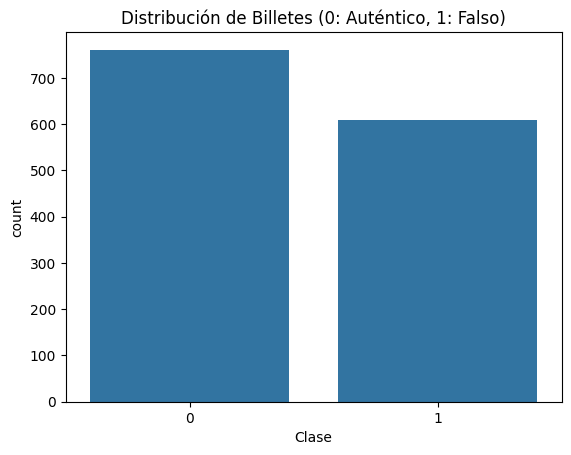

In [ ]:
print(Billetes['Clase'].value_counts())
sns.countplot(x='Clase', data=Billetes)
plt.title("Distribución de Billetes (0: Auténtico, 1: Falso)")
plt.show()

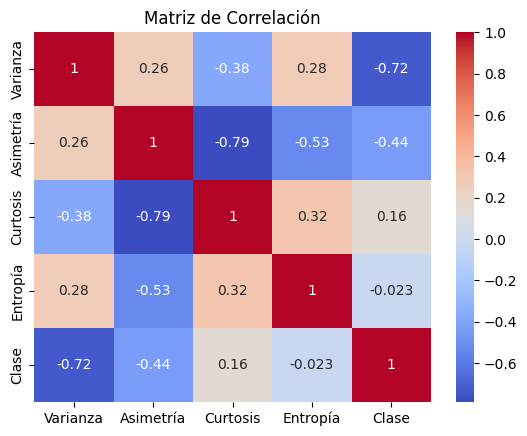

In [ ]:
sns.heatmap(Billetes.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

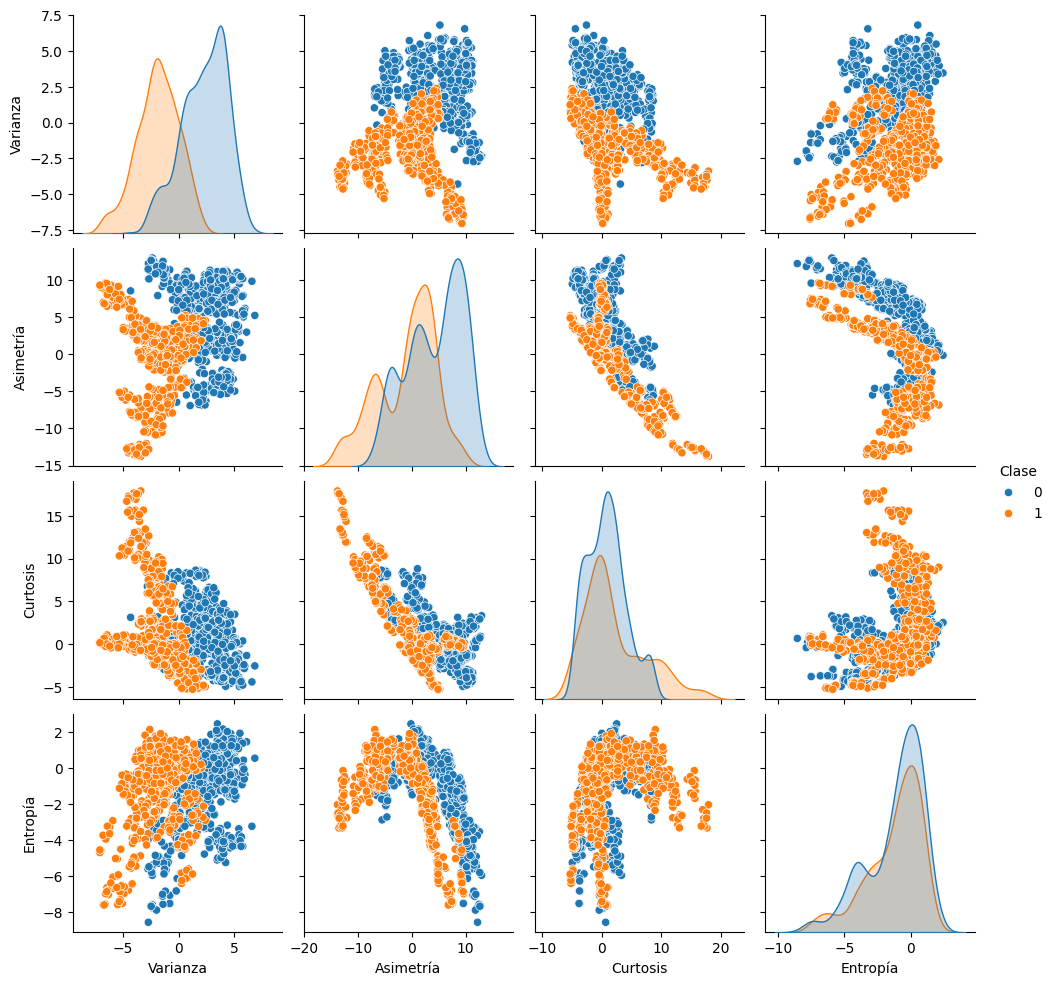

In [ ]:
sns.pairplot(Billetes, hue='Clase', diag_kind='kde')
plt.show()

In [ ]:
X = Billetes.drop('Clase', axis=1)
y = Billetes['Clase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

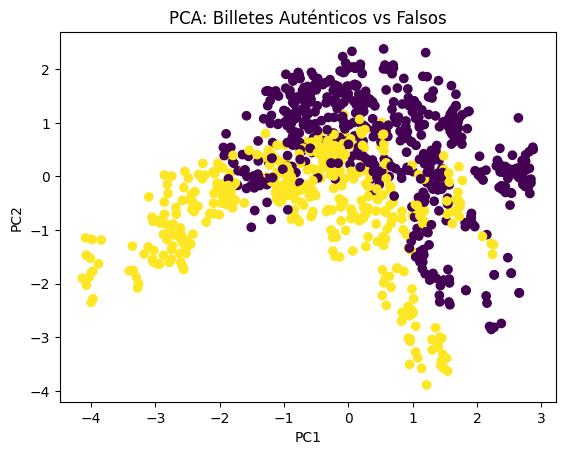

Varianza explicada: [0.54040927 0.32844927]


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Graficar
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("PCA: Billetes Auténticos vs Falsos")
plt.show()

print("Varianza explicada:", pca.explained_variance_ratio_)

Accuracy: 0.9805825242718447


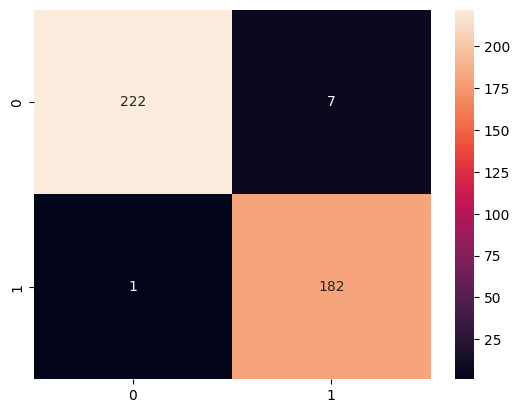

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       229
           1       0.96      0.99      0.98       183

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412



In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()
print(classification_report(y_test, y_pred))


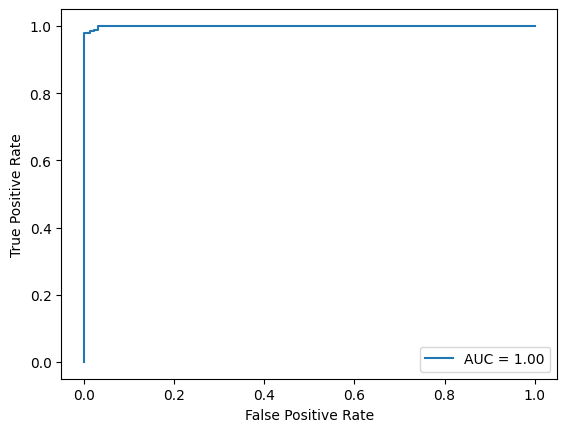

In [ ]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)  # Sin escalar (RF no lo necesita)
y_pred_rf = model_rf.predict(X_test)

print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))

Accuracy RF: 0.9878640776699029


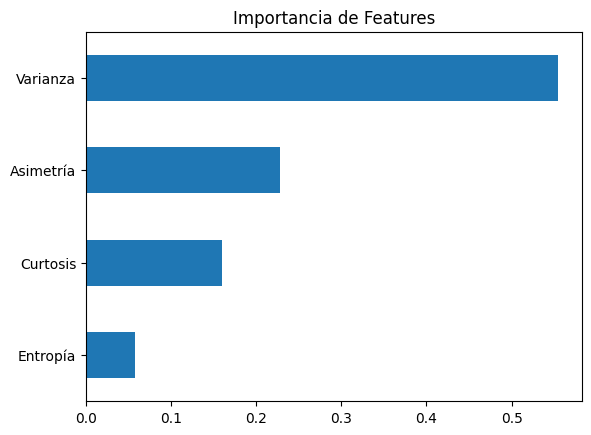

In [ ]:
feature_imp = pd.Series(model_rf.feature_importances_, index=X.columns)
feature_imp.sort_values().plot(kind='barh')
plt.title("Importancia de Features")
plt.show()

In [ ]:
# prompt: Genera un gráfico del PCA en 3D

import pandas as pd
# Apply PCA for 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

# Create a DataFrame for plotting
pca_df_3d = pd.DataFrame(data = X_pca_3d, columns = ['PC1', 'PC2', 'PC3'])
pca_df_3d['Clase'] = y_train.reset_index(drop=True)

# Plot using Plotly
fig = px.scatter_3d(pca_df_3d, x='PC1', y='PC2', z='PC3',
              color='Clase', title='PCA: Billetes Auténticos vs Falsos en 3D')
fig.show()